In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target),(test_input, test_target) = keras.datasets.fashion_mnist.load_data()
train_scaled= train_input/ 255.0
#변수명 보통 x_train/train_target 딥러닝 머신러닝 다름
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled,train_target,
    test_size=0.2,
    random_state=42
)

#Model 함수 구현

In [14]:
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28,28)))#reshape 대신 Flatten
    model.add(keras.layers.Dense(100, activation='relu'))

    if a_layer:#list안에 있으면 못바꿈
        model.add(a_layer)
    model.add(keras.layers.Dense(10,activation='softmax'))
    return model#<<<<<<<<<<<<<<<<<<<<<<,

In [15]:
#모델 구성 및 Summary
model = model_fn()
model.summary()#인풋

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#훈련 및 과정에 대한 history 보기
model.compile(loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history=model.fit(train_scaled,train_target,epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 815us/step - accuracy: 0.8150 - loss: 0.5206
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - accuracy: 0.8584 - loss: 0.3910
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step - accuracy: 0.8719 - loss: 0.3550
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 710us/step - accuracy: 0.8792 - loss: 0.3334
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 698us/step - accuracy: 0.8851 - loss: 0.3192



#손실곡선

In [17]:
history.history.keys()#딕셔너리

dict_keys(['accuracy', 'loss'])

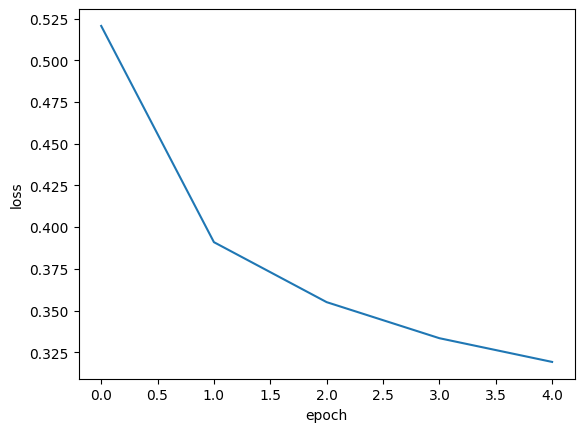

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')

plt.show()

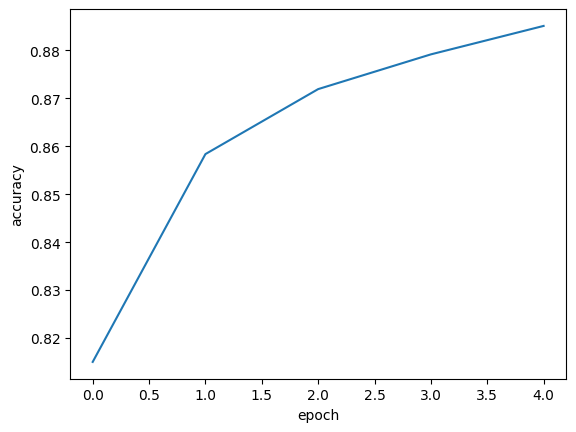

In [ ]:
#History의 Accuracy

plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')

plt.show()

반복훈련의 증가(epoch 증가)

In [20]:
model= model_fn()

model.compile(loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history=model.fit(train_scaled,train_target,epochs=20)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - accuracy: 0.8107 - loss: 0.5337
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 810us/step - accuracy: 0.8589 - loss: 0.3927
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - accuracy: 0.8719 - loss: 0.3550
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 907us/step - accuracy: 0.8809 - loss: 0.3328
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accuracy: 0.8852 - loss: 0.3159
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 891us/step - accuracy: 0.8905 - loss: 0.3063
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 885us/step - accuracy: 0.8959 - loss: 0.2934
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 712us/step - accuracy: 0.8981 - loss: 0.2847
Epoch 9/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9018 - loss: 0.2767
Epoch 10/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step - accuracy: 0.9044 - loss: 0.2710
Epoch 11/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 748us/step - accuracy: 0.9071 - loss: 0.2643
Epoch 12/2

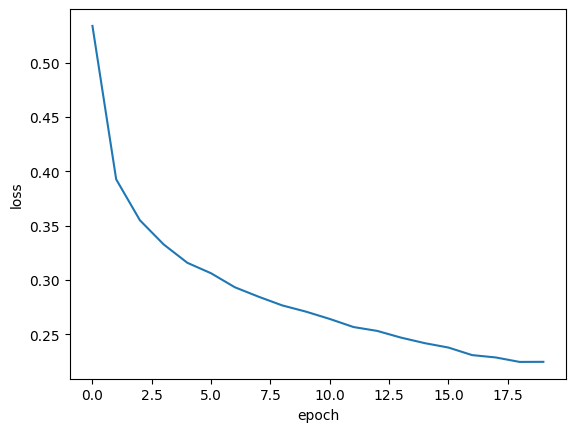

In [ ]:
#History의 loss??
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')

plt.show()
#훈련시 트레인, 밸리드 보면서(과대적합 방지)

훈련세트에만 정확도가 높고 검증세트나 테스트세트에서는 정확도가 떨어지는 과대적합이 생길수 있다.
epoch를 무한정 늘리면 훈련세트에만 정확도가 높아질 수 있어 검증세트나 테스트 세트에서도 정확도가 높은 지점을 찾아야한다.
=>불리야스????/양주

---
###검증 손실
:검증세트에 대한 정확도를 파악하기 위해 validation_data를 사용한다.

In [22]:
model = model_fn()

model.compile(loss='sparse_categorical_crossentropy',metrics=['accuracy'])#정확도
history=model.fit(train_scaled,train_target,epochs=20, validation_data=(val_scaled,val_target))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8147 - loss: 0.5295 - val_accuracy: 0.8540 - val_loss: 0.4077
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - accuracy: 0.8605 - loss: 0.3878 - val_accuracy: 0.8649 - val_loss: 0.3675
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8723 - loss: 0.3513 - val_accuracy: 0.8671 - val_loss: 0.3812
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 860us/step - accuracy: 0.8807 - loss: 0.3310 - val_accuracy: 0.8743 - val_loss: 0.3556
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8859 - loss: 0.3151 - val_accuracy: 0.8665 - val_loss: 0.4054
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8926 - loss: 0.3024 - val_accuracy: 0.8763 - val_loss: 0.3683
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step - accuracy: 0.8970 - loss: 0.2932 - val_accuracy: 0.8813 - val_loss: 0.3549
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 823us/step - accuracy: 0.8995 - loss: 0

In [ ]:
history.history.keys()#추가됨

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

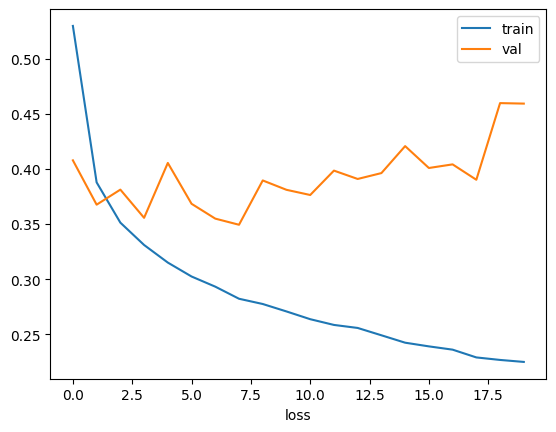

In [ ]:
#시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.xlabel('loss')
plt.legend(['train','val'])
plt.show()
#2번일떄가 비슷스#과대적합 가능성 있음=>optimize(loss check/sgd:0.001?)

In [25]:
model = model_fn()

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])#정확도
history=model.fit(train_scaled,train_target,epochs=20, validation_data=(val_scaled,val_target))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8185 - loss: 0.5224 - val_accuracy: 0.8429 - val_loss: 0.4243
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8595 - loss: 0.3910 - val_accuracy: 0.8640 - val_loss: 0.3770
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step - accuracy: 0.8736 - loss: 0.3519 - val_accuracy: 0.8698 - val_loss: 0.3598
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8800 - loss: 0.3284 - val_accuracy: 0.8690 - val_loss: 0.3635
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8882 - loss: 0.3061 - val_accuracy: 0.8711 - val_loss: 0.3469
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8926 - loss: 0.2913 - val_accuracy: 0.8830 - val_loss: 0.3261
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step - accuracy: 0.8968 - loss: 0.2778 - val_accuracy: 0.8845 - val_loss: 0.3236
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step - accuracy: 0.9023 - loss: 0.2

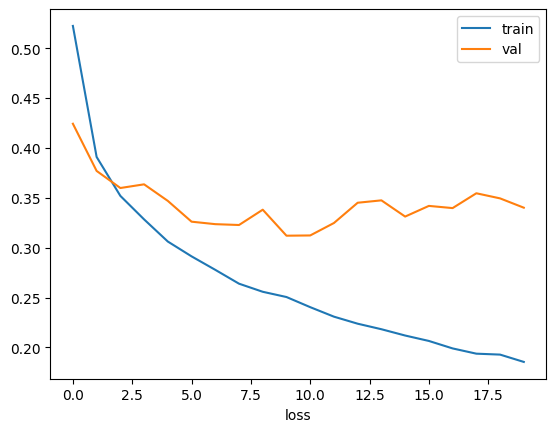

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.xlabel('loss')
plt.legend(['train','val'])
plt.show()#완만해짐 상대적으로

----
####DropOut(규제)
-과대적합 방지를 위한 규제(머신러닝에서는 L1:랏소,L2:릿지 규제)
-신경망 모델에만 있음
-훈련 시에만 각 sample 을 처리할때마다 은닉층의 임의의 neuron을 계산에 포함시키지 않는다.

In [ ]:
#학습못하게 공식을 하나씩 지움
#model에 dropout층을 추가
model= model_fn(keras.layers.Dropout(0.3)) #dropout을 30%/은닉층을 늘리는 방법도 있음#하이퍼파라미터 없음
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(loss='sparse_categorical_crossentropy',metrics=['accuracy'])#정확도
history=model.fit(train_scaled,train_target,epochs=20, validation_data=(val_scaled,val_target))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7956 - loss: 0.5802 - val_accuracy: 0.8304 - val_loss: 0.4706
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 899us/step - accuracy: 0.8442 - loss: 0.4450 - val_accuracy: 0.8500 - val_loss: 0.4125
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 807us/step - accuracy: 0.8527 - loss: 0.4182 - val_accuracy: 0.8638 - val_loss: 0.3873
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - accuracy: 0.8597 - loss: 0.4018 - val_accuracy: 0.8673 - val_loss: 0.3945
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 921us/step - accuracy: 0.8634 - loss: 0.3959 - val_accuracy: 0.8657 - val_loss: 0.3867
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step - accuracy: 0.8662 - loss: 0.3876 - val_accuracy: 0.8773 - val_loss: 0.3687
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 868us/step - accuracy: 0.8674 - loss: 0.3850 - val_accuracy: 0.8753 - val_loss: 0.3746
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8721 - los

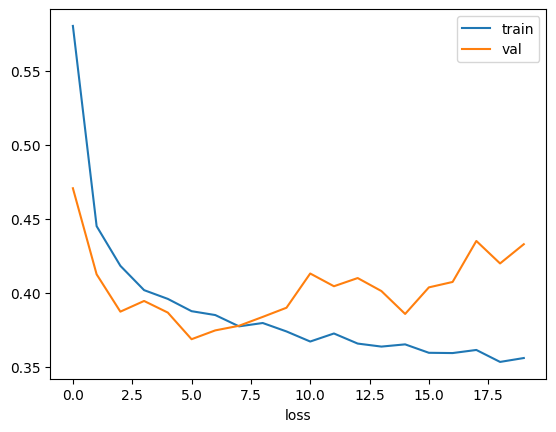

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.xlabel('loss')
plt.legend(['train','val'])
plt.show()#많이 근접했음

----
####모델의 저장과 복원


In [ ]:
#저장 
model.save("../Data/model_whole.keras")

In [ ]:
#사용
model1 = keras.models.load_model("../Data/model_whole.keras")

In [ ]:
model1.evaluate(val_scaled,val_target)#957K#모델의 컬럼수가 좌지우지함

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step - accuracy: 0.8816 - loss: 0.4328


[0.4328138530254364, 0.8815833330154419]

----
####Callbacks
:훈련 수행시 손실값이 제일 작은 함수를 저장해준다.<- 굉장히 편하다.

In [ ]:
model= model_fn(keras.layers.Dropout(0.3)) 

model.compile(loss='sparse_categorical_crossentropy',metrics=['accuracy'])

checkpoint_db= keras.callbacks.ModelCheckpoint("../Data/best_model.keras")

In [34]:

history=model.fit(train_scaled,train_target,epochs=20, validation_data=(val_scaled,val_target),callbacks=[checkpoint_db])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7915 - loss: 0.5867 - val_accuracy: 0.8496 - val_loss: 0.4164
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step - accuracy: 0.8414 - loss: 0.4452 - val_accuracy: 0.8587 - val_loss: 0.3884
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - accuracy: 0.8515 - loss: 0.4205 - val_accuracy: 0.8627 - val_loss: 0.3839
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step - accuracy: 0.8614 - loss: 0.4026 - val_accuracy: 0.8457 - val_loss: 0.4473
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.8644 - loss: 0.3883 - val_accuracy: 0.8705 - val_loss: 0.3926
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - accuracy: 0.8659 - loss: 0.3885 - val_accuracy: 0.8676 - val_loss: 0.3916
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 788us/step - accuracy: 0.8686 - loss: 0.3833 - val_accuracy: 0.8767 - val_loss: 0.3712
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - accuracy: 0.8721 - l

In [ ]:
#사용
model1 = keras.models.load_model("../Data/best_model.keras")
model1.evaluate(val_scaled,val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step - accuracy: 0.8769 - loss: 0.4208


[0.42078375816345215, 0.8769166469573975]

----
####Early-Stopping(조기종료)
:CallBacks를 끝까지 기다리는 것이 아니고 Hyper Parameter(patience:참을성)을 선정하여 한계값을 정해 실행한다.

In [ ]:
#callback 함수 epoch 어쩌구?? #__함수 기준
model= model_fn(keras.layers.Dropout(0.3)) #dropout을 30%/은닉층을 늘리는 방법도 있음#하이퍼파라미터 없음

model.compile(loss='sparse_categorical_crossentropy',metrics=['accuracy'])

checkpoint_cb= keras.callbacks.ModelCheckpoint("../Data/best_model.keras")

early_stopping_cb= keras.callbacks.EarlyStopping(patience=2,restore_best_weights=True)

history=model.fit(train_scaled,train_target,epochs=20, validation_data=(val_scaled,val_target),callbacks=[checkpoint_db,early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 983us/step - accuracy: 0.7930 - loss: 0.5909 - val_accuracy: 0.8428 - val_loss: 0.4286
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step - accuracy: 0.8401 - loss: 0.4465 - val_accuracy: 0.8531 - val_loss: 0.4128
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - accuracy: 0.8530 - loss: 0.4173 - val_accuracy: 0.8658 - val_loss: 0.3841
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 931us/step - accuracy: 0.8605 - loss: 0.4014 - val_accuracy: 0.8735 - val_loss: 0.3676
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - accuracy: 0.8639 - loss: 0.3923 - val_accuracy: 0.8727 - val_loss: 0.3754
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 805us/step - accuracy: 0.8677 - loss: 0.3841 - val_accuracy: 0.8726 - val_loss: 0.3879


In [47]:
#몇번쨰 epoch에서 stop되었는가
early_stopping_cb.stopped_epoch

5

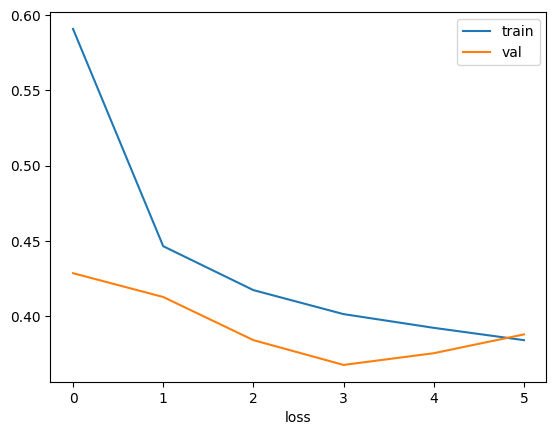

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.xlabel('loss')
plt.legend(['train','val'])
plt.show()

In [49]:
model.evaluate(val_scaled,val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - accuracy: 0.8735 - loss: 0.3676


[0.3676376938819885, 0.8734999895095825]